# Visualizador
Esse notebook será o usado para mostrar como o algoritmo funciona: retirando o smooth da imagem e preservando as bordas

## Preparação do notebook

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print(hasattr(cv2, "ximgproc"))
print(hasattr(cv2.ximgproc, "guidedFilter"))

True
True


## Aplicação do filtro e Comparação com o filtro Canny

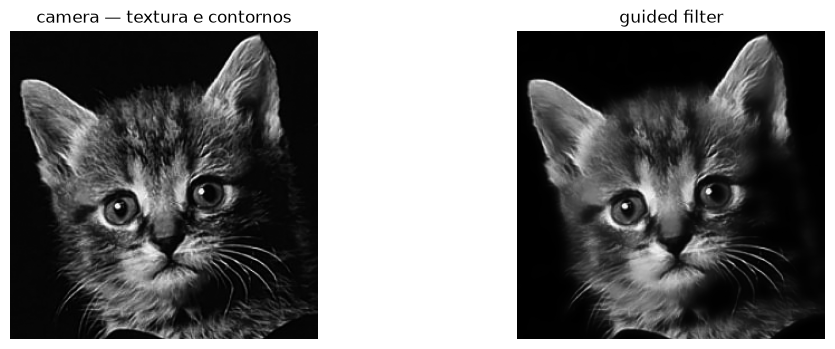

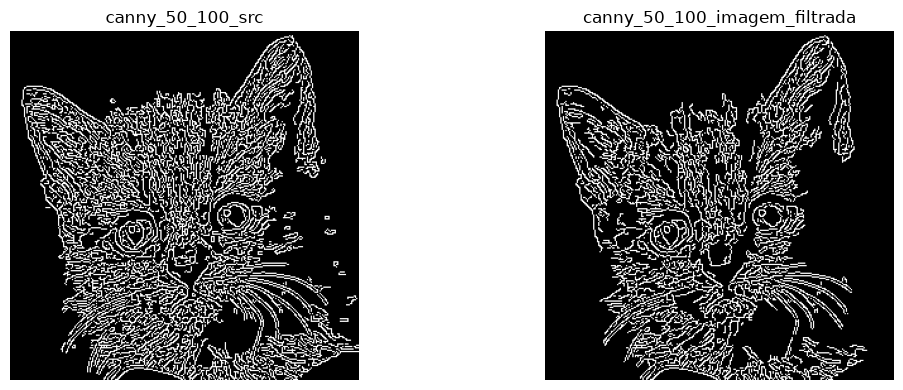

In [3]:
QUANTIDADE_IMAGENS = 1  # Define a quantidade de imagens a serem processadas.

lista_imagens = []
lista_imagens_filtradas = []


# Parâmetros: raio do filtro (radius) e regularização (eps)
radius = 4
eps = 0.01  # Exemplo de escala para imagens de 8 bits


for i in range(1, QUANTIDADE_IMAGENS+1):

    caminho_entrada = f"images/imagem{i:02d}.pgm"
    caminho_saida = f"images_pgm_py_filtradas/resultado{i:02d}.pgm"


    src = cv2.imread(caminho_entrada, cv2.IMREAD_GRAYSCALE)

    lista_imagens.append(src)

    src = src.astype(np.float32) / 255.0

    # Aplicação direta do Guided Filter
    output_expected = cv2.ximgproc.guidedFilter(guide=src, src=src, radius=radius, eps=eps) # aplicação do filtro em float

    output_expected = (output_expected * 255).astype(np.uint8) # cast da saida de float para usigned char

    cv2.imwrite(caminho_saida, output_expected)

    lista_imagens_filtradas.append(output_expected)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Cria três painéis para apresentar as imagens de referência.
axes[0].imshow(lista_imagens[0], cmap="gray", vmin=0, vmax=255)  # Exibe a imagem camera em tons de cinza.
axes[0].set_title("camera — textura e contornos")  # Explica a característica principal da primeira imagem.
axes[0].axis('off')

axes[1].imshow(lista_imagens_filtradas[0], cmap="gray")  # Exibe a imagem em tons de cinza.
axes[1].set_title("guided filter")  # Explica a característica principal da segunda imagem.
axes[1].axis('off')

canny_50_100 = cv2.Canny(lista_imagens[0], 50, 100)  # Executa Canny com limiares mais baixos.
canny_50_100_2 = cv2.Canny(lista_imagens_filtradas[0], 50, 100)  # Executa Canny com limiares mais baixos.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Cria quatro painéis para comparar a influência dos limiares.
axes[0].imshow(canny_50_100, cmap="gray", vmin=0, vmax=255)  # Exibe a imagem camera em tons de cinza.
axes[0].set_title("canny_50_100_src")  # Explica a característica principal da primeira imagem.
axes[0].axis('off')
axes[1].imshow(canny_50_100_2, cmap="gray", vmin=0, vmax=255)  # Exibe a imagem em tons de cinza.
axes[1].set_title("canny_50_100_imagem_filtrada")  # Explica a característica principal da segunda imagem.
axes[1].axis('off')


plt.tight_layout()  # Ajusta os espaçamentos.
plt.show()  # Renderiza a comparação.
